<a href="https://colab.research.google.com/github/hasby-umutoniwabo/TimeSeriesForecasting-formative/blob/main/notebooks/02_eda_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Drive and load our saved data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

save_dir = "/content/drive/MyDrive/milan_traffic_project"
loaded = np.load(f"{save_dir}/traffic_matrix.npz", allow_pickle=True)

traffic = loaded["traffic"]          # shape (8928 time slots, 10000 grid squares)
timestamps = pd.to_datetime(loaded["timestamps"])

print("traffic shape:", traffic.shape)
print("time range:", timestamps[0], "to", timestamps[-1])

Mounted at /content/drive
traffic shape: (8928, 10000)
time range: 2013-10-31 23:00:00 to 2014-01-01 22:50:00


Total traffic per area, across the whole 2 months

In [2]:
# sum across time (axis 0) gives us one total number per grid square
total_per_area = traffic.sum(axis=0)

print("min:", total_per_area.min())
print("max:", total_per_area.max())
print("mean:", total_per_area.mean())
print("median:", np.median(total_per_area))

min: 213.62668
max: 12740066.0
mean: 555289.4
median: 277871.38


Plot the distribution

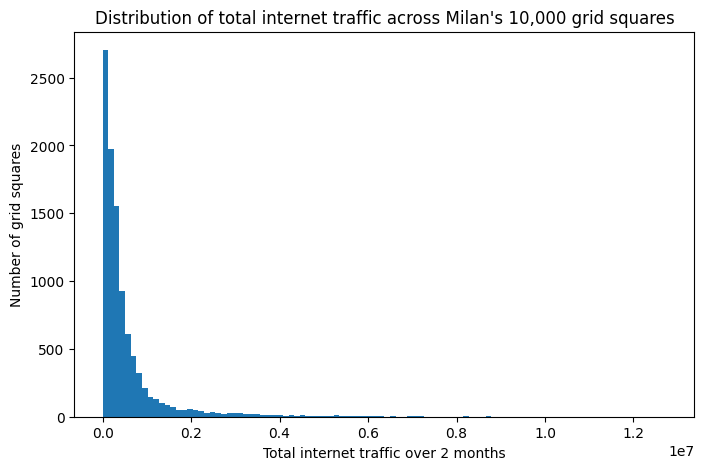

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(total_per_area, bins=100)
plt.xlabel("Total internet traffic over 2 months")
plt.ylabel("Number of grid squares")
plt.title("Distribution of total internet traffic across Milan's 10,000 grid squares")
plt.savefig("distribution_total_traffic.png", dpi=150, bbox_inches="tight")
plt.show()

Log-scale version of the same plot

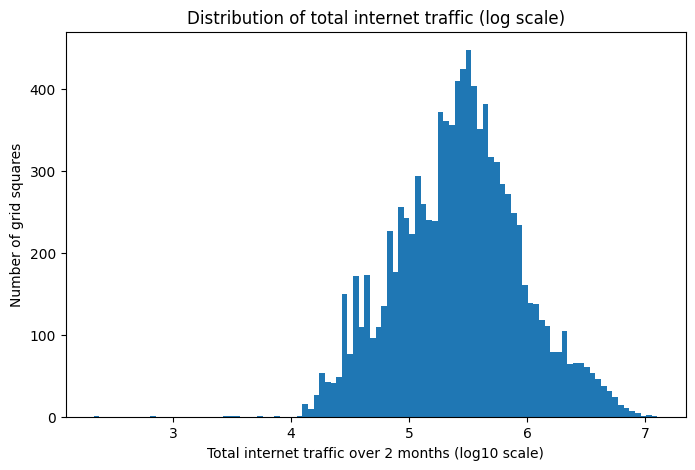

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(np.log10(total_per_area), bins=100)
plt.xlabel("Total internet traffic over 2 months (log10 scale)")
plt.ylabel("Number of grid squares")
plt.title("Distribution of total internet traffic (log scale)")
plt.savefig("distribution_total_traffic_log.png", dpi=150, bbox_inches="tight")
plt.show()

Finding the top 3 highest-traffic areas

In [5]:
# GridID = index + 1, since the array columns are 0-indexed but grid squares are numbered from 1
top3_idx = np.argsort(total_per_area)[-3:][::-1]   # top 3, highest first
top3_grid_ids = top3_idx + 1

for rank, (idx, grid_id) in enumerate(zip(top3_idx, top3_grid_ids), start=1):
    print(f"#{rank}: GridID {grid_id}  ->  total traffic {total_per_area[idx]:,.0f}")

#1: GridID 5161  ->  total traffic 12,740,066
#2: GridID 5059  ->  total traffic 11,170,843
#3: GridID 5259  ->  total traffic 10,485,784


Extract 2 weeks for our 5 areas of interest

In [6]:
# first 2 weeks = 14 days * 24 hours * 6 slots per hour (10-min intervals)
two_weeks_slots = 14 * 24 * 6

areas_of_interest = {
    "5161 (top 1)": 5161,
    "5059 (top 2)": 5059,
    "5259 (top 3)": 5259,
    "4159 (given)": 4159,
    "4556 (given)": 4556,
}

# grab just the first 2 weeks of data for these 5 columns only (memory-friendly slicing)
subset = {}
for label, grid_id in areas_of_interest.items():
    col_idx = grid_id - 1  # GridID to array index
    subset[label] = traffic[:two_weeks_slots, col_idx]

time_subset = timestamps[:two_weeks_slots]
print("slots per area:", two_weeks_slots)

slots per area: 2016


Plotting all 5 as separate subplots(easier to compare shape than one crowded chart)

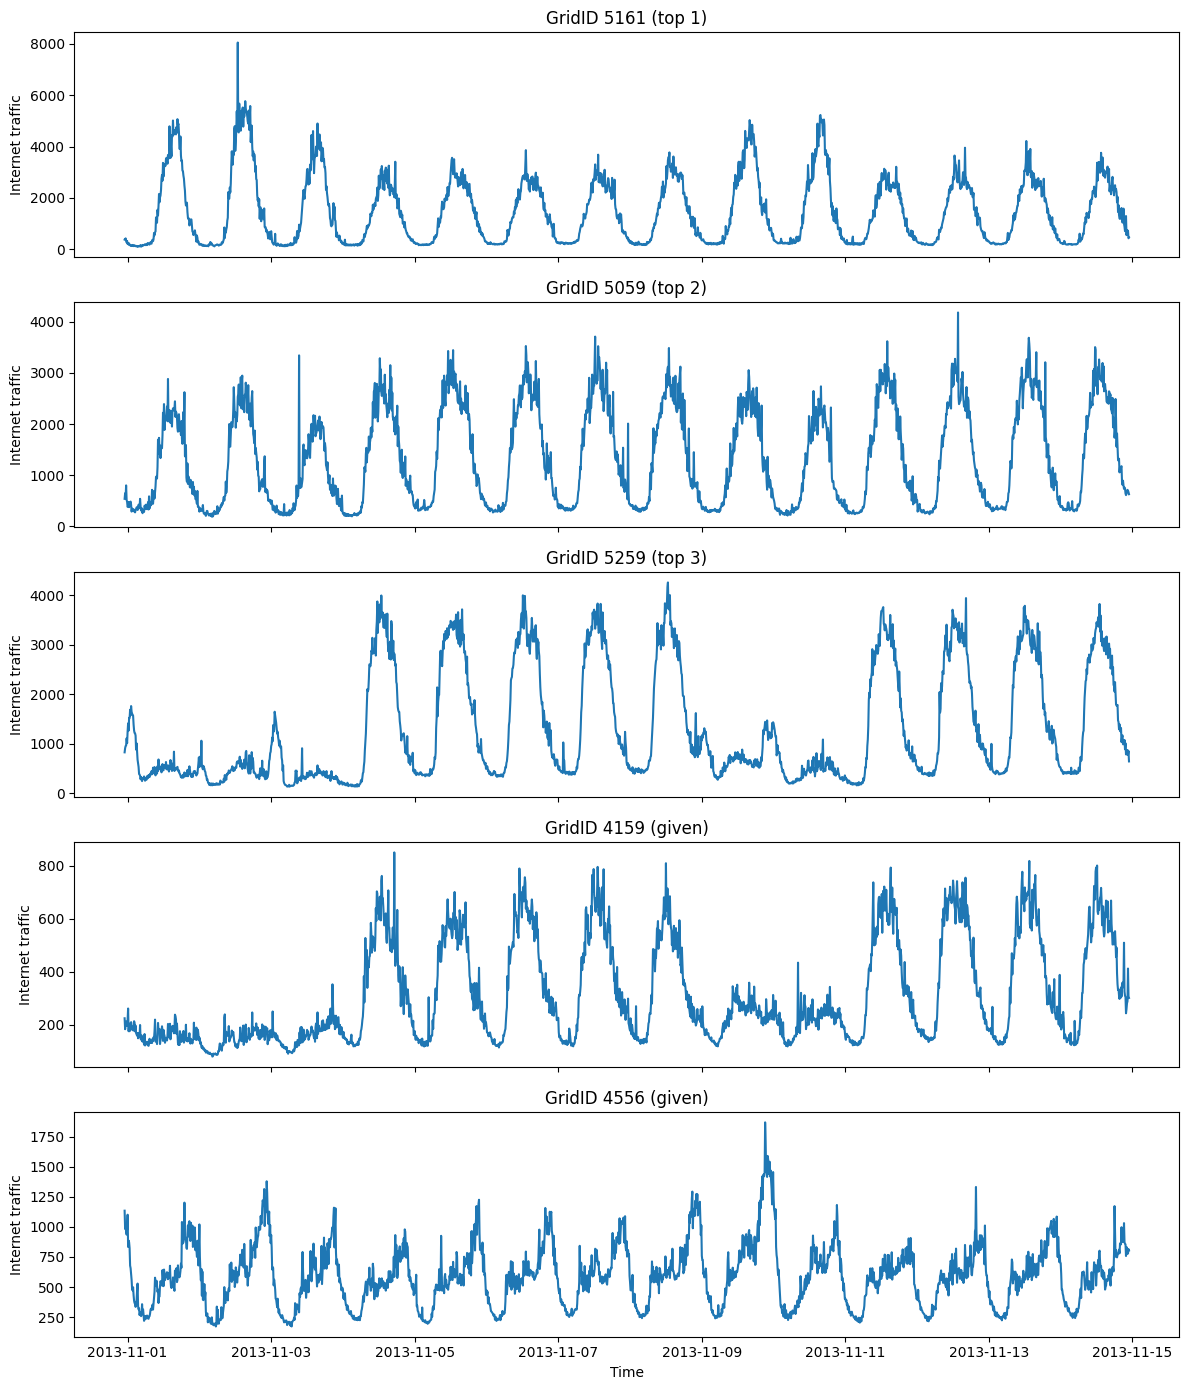

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for ax, (label, values) in zip(axes, subset.items()):
    ax.plot(time_subset, values)
    ax.set_title(f"GridID {label}")
    ax.set_ylabel("Internet traffic")

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.savefig("timeseries_first_two_weeks.png", dpi=150, bbox_inches="tight")
plt.show()

autocorrelation analysis on GridID 5161 (reveals daily/weekly periodicity precisely)

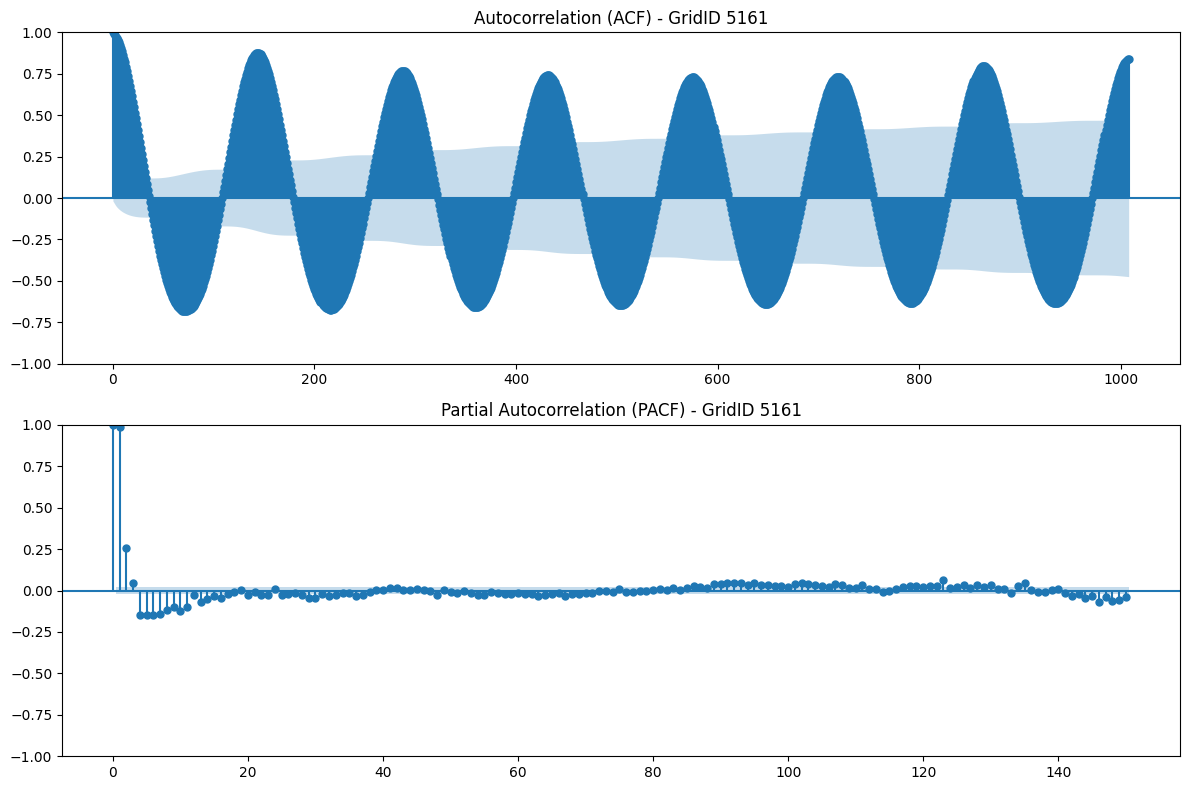

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

col_5161 = traffic[:, 5161 - 1]  # full 2 months of data for this area

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(col_5161, lags=1008, ax=axes[0])   # 1008 = 7 days worth of 10-min slots, shows weekly pattern
axes[0].set_title("Autocorrelation (ACF) - GridID 5161")

plot_pacf(col_5161, lags=150, ax=axes[1])   # shorter lag window, easier to read
axes[1].set_title("Partial Autocorrelation (PACF) - GridID 5161")

plt.tight_layout()
plt.savefig("acf_pacf_5161.png", dpi=150, bbox_inches="tight")
plt.show()

Seasonal decomposition (splits the series into trend, daily seasonality, and leftover noise)

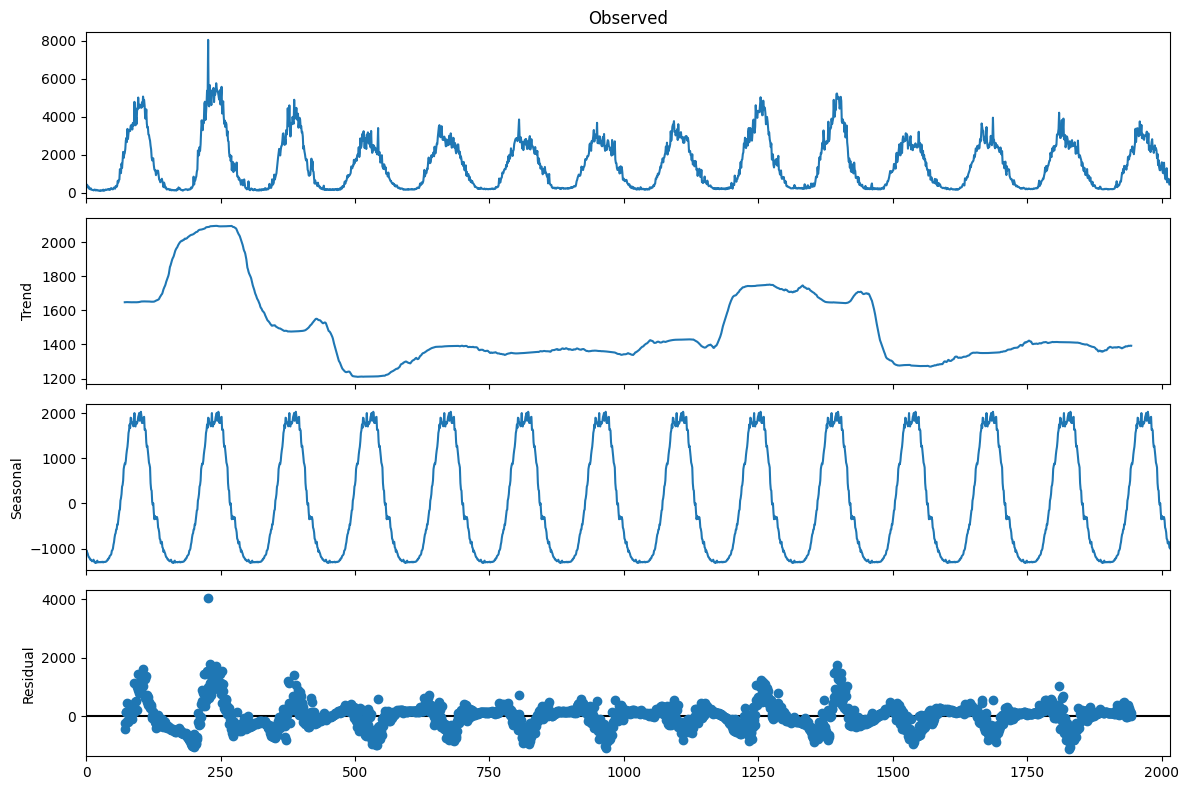

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 144 = one full day's worth of 10-min slots (24*6), tells statsmodels the seasonal period
decomposition = seasonal_decompose(col_5161[:two_weeks_slots], model="additive", period=144)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("decomposition_5161.png", dpi=150, bbox_inches="tight")
plt.show()